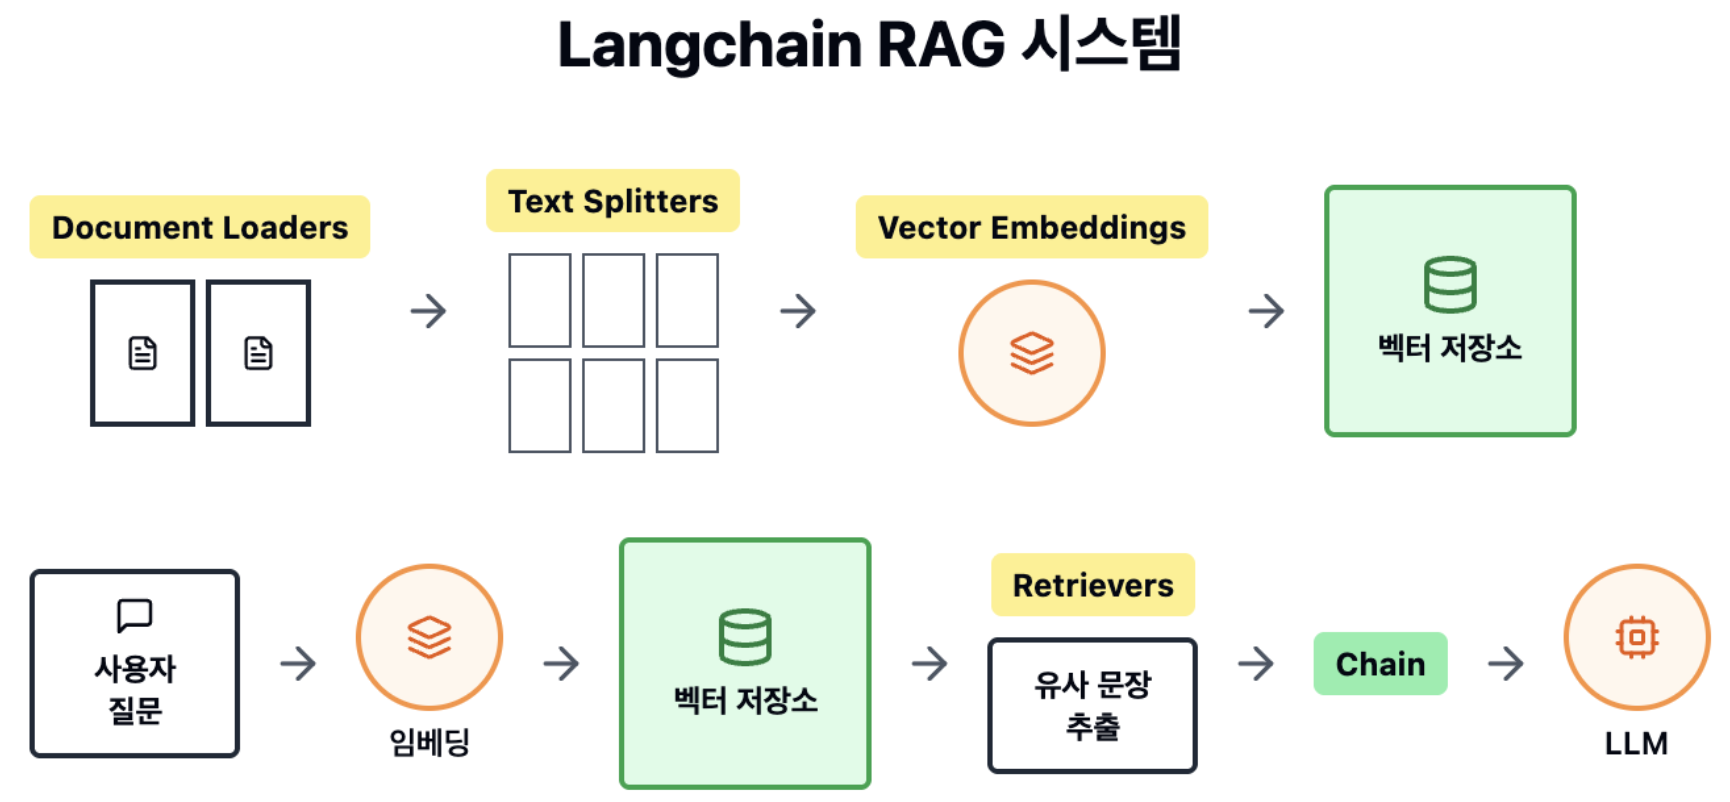

## [Embedding](https://docs.langchain.com/oss/python/integrations/text_embedding/index#embedding-models)

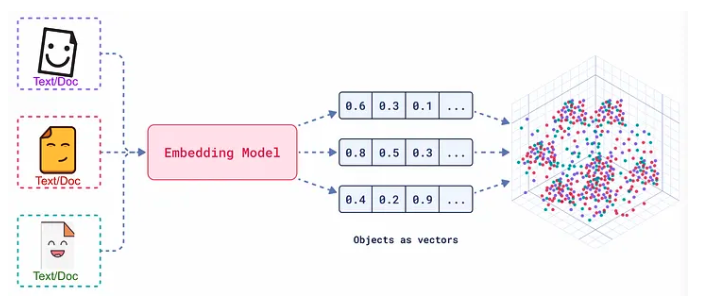

- 임베딩(Embedding)은 텍스트 데이터를 숫자로 이루어진 벡터로 변환하는 과정을 말합니다.
- 이러한 벡터 표현을 사용하면, 텍스트 데이터를 벡터 공간 내에서 수학적으로 다룰 수 있게 되며, 이를 통해 텍스트 간의 유사성을 계산하거나, 텍스트 데이터를 기반으로 하는 다양한 머신러닝 및 자연어 처리 작업을 수행할 수 있습니다.
- 임베딩 과정은 텍스트의 의미적인 정보를 보존하도록 설계되어 있어, 벡터 공간에서 가까이 위치한 텍스트 조각들은 의미적으로도 유사한 것으로 간주됩니다.

임베딩의 주요 활용 사례:
- `의미 검색(Semantic Search)`: 벡터 표현을 활용하여 의미적으로 유사한 텍스트를 검색하는 과정으로, 사용자가 입력한 쿼리에 대해 가장 관련성 높은 문서나 정보를 찾아내는 데 사용됩니다.
- `문서 분류(Document Classification)`: 임베딩된 텍스트 벡터를 사용하여 문서를 특정 카테고리나 주제에 할당하는 분류 작업에 사용됩니다.
- `텍스트 유사도 계산(Text Similarity Calculation)`: 두 텍스트 벡터 사이의 거리를 계산하여, 텍스트 간의 유사성 정도를 정량적으로 평가합니다.

임베딩 모델 제공자:
- `OpenAI`: GPT와 같은 언어 모델을 통해 텍스트의 임베딩 벡터를 생성할 수 있는 API를 제공합니다.
- `Hugging Face`: Transformers 라이브러리를 통해 다양한 오픈소스 임베딩 모델을 제공합니다.
- `Google`: Gemini, Gemma 등 언어 모델에 적용되는 임베딩 모델을 제공합니다.

임베딩 메소드:
- `embed_documents`: 이 메소드는 문서 객체의 집합을 입력으로 받아, 각 문서를 벡터 공간에 임베딩합니다. 주로 대량의 텍스트 데이터를 배치 단위로 처리할 때 사용됩니다.
- `embed_query`: 이 메소드는 단일 텍스트 쿼리를 입력으로 받아, 쿼리를 벡터 공간에 임베딩합니다. 주로 사용자의 검색 쿼리를 임베딩하여, 문서 집합 내에서 해당 쿼리와 유사한 내용을 찾아내는 데 사용됩니다.

임베딩은 텍스트 데이터를 머신러닝 모델이 이해할 수 있는 형태로 변환하는 핵심 과정입니다. 다양한 자연어 처리 작업의 기반이 되는 중요한 작업입니다.

# Setup

## API Key 등록 
- [Huggingface 토큰 등록](https://huggingface.co/settings/tokens)

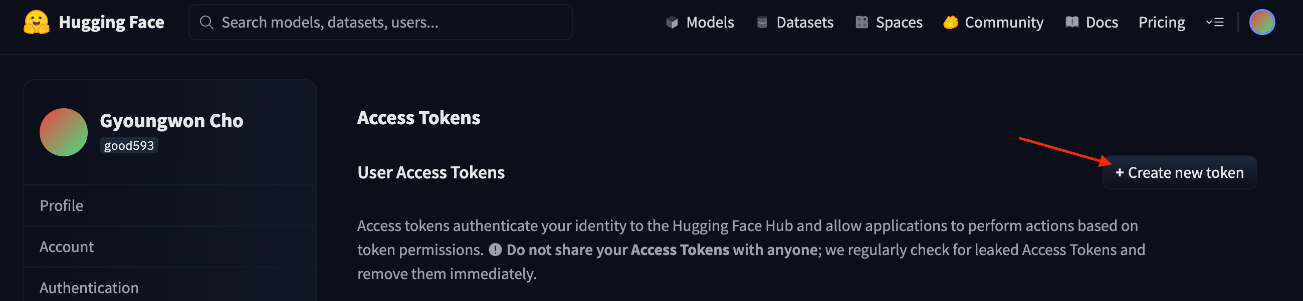

In [1]:
from dotenv import load_dotenv 

load_dotenv()


True

# Embedding 테스트용 함수

In [2]:
from sklearn.metrics.pairwise import cosine_similarity

def similarity(a, b):
    """
    두 벡터 a, b의 코사인 유사도를 계산하여 반환하는 함수.

    코사인 유사도(cosine similarity):
    - 두 벡터의 방향이 얼마나 유사한지를 0~1 사이 값으로 계산
    - 1에 가까울수록 두 벡터가 더 비슷한 의미를 가진다고 해석할 수 있음
    - NLP 임베딩 벡터 비교에서 가장 널리 사용되는 방식

    cosine_similarity의 입력 형식:
    - 2D 배열을 입력으로 받기 때문에 [a], [b]처럼 리스트로 한 번 더 감싸야 함
    """

    # sklearn의 cosine_similarity는 2차원 배열을 입력받기 때문에
    # 각각의 벡터를 [a], [b] 형태로 감싸서 전달
    return cosine_similarity([a], [b])[0][0]


In [3]:
def test_embedding(embedding_model):
    # 임베딩을 테스트할 문장 리스트
    sentences = [
        '안녕하세요!',
        '어! 오랜만이에요',
        '이름이 어떻게 되세요?',
        '날씨가 추워요',
        'Hello LLM!'
    ]

    # 임베딩된 문장들과 유사도를 비교할 질의(query)
    query = '첫인사를 하고 이름을 물어봤나요?'

    # 문장 리스트에 대해 임베딩 벡터 생성
    embeddings = embedding_model.embed_documents(sentences)

    # 질의(query) 문장에 대한 임베딩 벡터 생성
    embedded_query = embedding_model.embed_query(query)

    # 각 문장 임베딩과 질의 임베딩 간 유사도 계산 및 출력
    for i, embedding in enumerate(embeddings):
        print(
            f"""
            [유사도 {similarity(embedding, embedded_query):.4f}] {query} \t <=====> \t {sentences[i]}
            """
        )


# [HuggingFace Embedding Models](https://huggingface.co/models?sort=trending&search=Embedding)
- `sentence-transformers` 라이브러리를 사용하면 HuggingFace 모델에서 사용된 사전 훈련된 임베딩 모델을 다운로드 받아서 적용할 수 있습니다.
- OpenAI 임베딩 모델을 사용할 때는 API 사용료가 부과되지만, HuggingFace의 오픈소스 기반의 임베딩 모델을 사용하면 요금이 부과되지 않습니다.

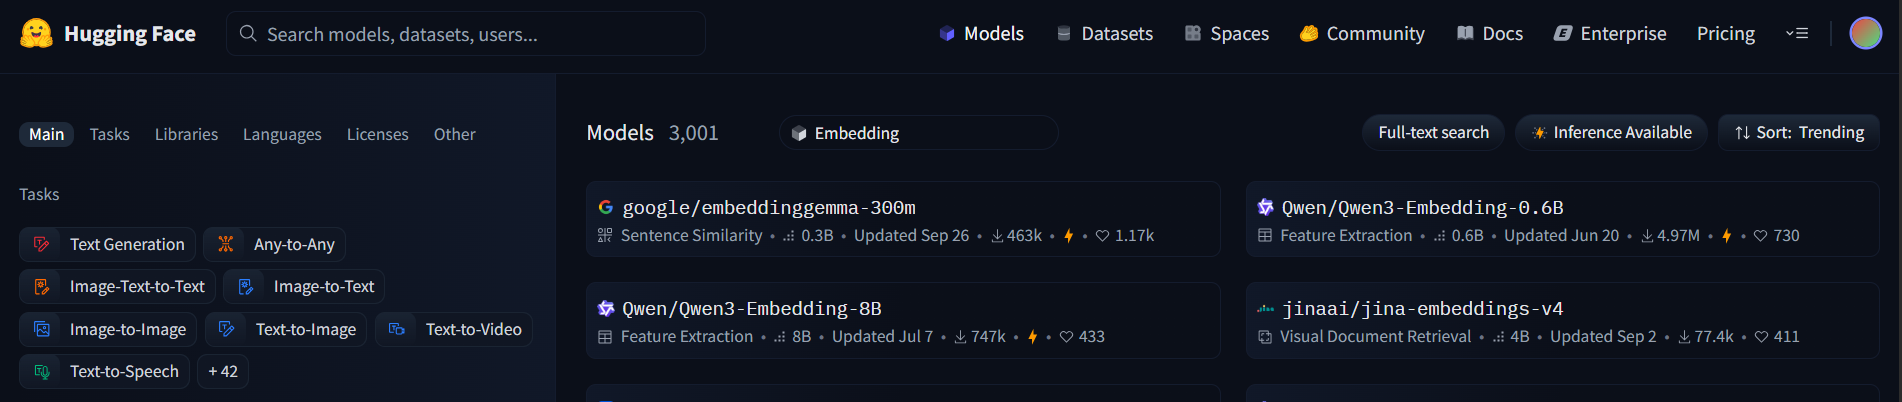

# [HuggingFaceEmbeddings](https://docs.langchain.com/oss/python/integrations/providers/huggingface#huggingfaceembeddings)

`HuggingFaceEmbeddings` 클래스는 Hugging Face의 트랜스포머 모델을 사용하여 문서 또는 문장을 임베딩하는 데 사용됩니다. 다음은 주요 매개변수의 설정 값을 설명합니다.
- `model_name='jhgan/ko-sroberta-nli'` : 사용할 모델을 지정합니다. 여기서는 한국어 자연어 추론(Natural Language Inference, NLI)에 최적화된 ko-sroberta 모델을 사용합니다.
- `model_kwargs={'device':'cpu'}` : 모델이 CPU에서 실행되도록 설정합니다. GPU를 사용할 수 있는 환경이라면 'cuda'로 설정할 수도 있습니다.
- `encode_kwargs={'normalize_embeddings':True}` : 임베딩을 정규화하여 모든 벡터가 같은 범위의 값을 갖도록 합니다. 이는 유사도 계산 시 일관성을 높여줍니다.

## [예제: Qwen3-Embedding-0.6B](https://huggingface.co/Qwen/Qwen3-Embedding-0.6B)

In [4]:
from langchain_huggingface.embeddings import HuggingFaceEmbeddings

# 사용할 임베딩 모델 이름 (HuggingFace Hub에 존재하는 모델)
model_name = "Qwen/Qwen3-Embedding-0.6B"

# HuggingFace Embedding 모델 초기화
embeddings_huggingface = HuggingFaceEmbeddings(
    model_name=model_name,          # 불러올 임베딩 모델 이름
    cache_folder="./models/",       # 모델 파일이 저장될 로컬 경로 (없으면 자동 생성)
    
    model_kwargs={
        "device": "cpu"             # 모델을 실행할 디바이스 설정 (cpu / cuda 등)
    },

    encode_kwargs={
        'normalize_embeddings': True  # 임베딩 벡터를 L2 정규화(norm)할지 여부
                                      # True → 코사인 유사도 계산 시 성능과 안정성 향상
    },
)


In [5]:
input_text = "The meaning of life is 42"
vector = embeddings_huggingface.embed_query(input_text)

print(f"변환된 벡터의 크기: {len(vector)}")

변환된 벡터의 크기: 1024


- test_embedding

In [6]:
test_embedding(embeddings_huggingface)


            [유사도 0.3801] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 안녕하세요!
            

            [유사도 0.3843] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 어! 오랜만이에요
            

            [유사도 0.4711] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 이름이 어떻게 되세요?
            

            [유사도 0.2640] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 날씨가 추워요
            

            [유사도 0.3414] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 Hello LLM!
            


## [예제: Qwen3-Embedding-4B](https://huggingface.co/Qwen/Qwen3-Embedding-4B)

In [7]:
from langchain_huggingface.embeddings import HuggingFaceEmbeddings

# 사용할 HuggingFace 임베딩 모델 (Qwen의 4B 임베딩 모델)
model_name = "Qwen/Qwen3-Embedding-4B"

# HuggingFace Embedding 모델 초기화
embeddings_huggingface = HuggingFaceEmbeddings(
    model_name=model_name,          # 로드할 임베딩 모델 이름 (HF Hub 기준)
    
    cache_folder="./models/",       # 모델 다운로드 및 로컬 캐싱 경로
                                    # 동일 경로에 있으면 재다운로드하지 않음
    
    model_kwargs={
        "device": "cpu"             # 모델이 실행될 디바이스 설정
                                    # "cpu", "cuda", "mps" 등 지원
    },
    
    encode_kwargs={
        'normalize_embeddings': True    # 임베딩 벡터 L2 정규화 여부
                                        # True → 코사인 유사도 계산 시 더 안정적
    },
)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [8]:
input_text = "The meaning of life is 42"
vector = embeddings_huggingface.embed_query(input_text)

print(f"변환된 벡터의 크기: {len(vector)}")

변환된 벡터의 크기: 2560


- test_embedding

In [9]:
test_embedding(embeddings_huggingface)


            [유사도 0.4455] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 안녕하세요!
            

            [유사도 0.4440] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 어! 오랜만이에요
            

            [유사도 0.6275] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 이름이 어떻게 되세요?
            

            [유사도 0.3777] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 날씨가 추워요
            

            [유사도 0.4295] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 Hello LLM!
            
